In [1]:
import sys

sys.path.append("..")

import matplotlib.pyplot as plt
import numpy as np
import random
from pulp import *

In [2]:
from candidate.candidate import Candidate
from voter.voter import Voter
from election.election import Election
from election.result import ElectionResult
from analysis.analyzer import ResultsAnalyzer

from strategy.strategy import VotingStrategy
from strategy.plurality import PluralityStrategy
from strategy.borda import BordaCountStrategy
from strategy.veto import VetoStrategy

from visualization.util import (
    plot,
    plot_results,
    random_2d_points,
    random_2d_point,
    plot_winner_distance_histogram,
    plot_lp_result,
    plot_lp_swap_result,
)

from calculation.calculation import find_farthest_pair, find_farthest_triple

from lp.lp import LpModel, PermutationLpModel, PermutationSwapLpModel

In [3]:
def verify_lp_winners(
    voter_positions: list[tuple[int, int]],
    candidates: list[Candidate],
    strategies: list[VotingStrategy],
    winners: dict[str, int],
):
    """Check that voters generated by the LP actually elect the target winners."""
    voters = [Voter(position=p) for p in voter_positions]
    election_result = Election(candidates=candidates, voters=voters).compare_strategies(
        strategies=strategies
    )

    print(f"voters: {len(voters)}\n")
    print(f"{'strategy':<12} {'target':>7} {'actual':>7}  ok")
    all_ok = True

    for strategy in strategies:
        target_idx = winners[strategy.key]
        actual_idx = candidates.index(election_result.winner(strategy))
        ok = target_idx == actual_idx
        all_ok &= ok
        print(
            f"{strategy.key:<12} {target_idx:>7} {actual_idx:>7}  {'OK' if ok else 'X'}"
        )

    assert all_ok, "LP model does NOT reproduce the target winners!"
    print("\nAll winners match - LP model is correct.")

In [4]:
def sample_voters(
    candidates: list[Candidate],
    shares: list[float],
    total: int,
    sigma: float = 1.0,
    seed: int | None = None,
) -> list[Voter]:
    """
    Sample voters around candidate positions using a Gaussian distribution.

    Parameters
    ----------
    candidates : list[Candidate]
        List of candidates, each with a .position (x, y) attribute.
    shares : list[float]
        Percentage of voters per candidate, same length as candidates.
        Must sum to 100.
    total : int
        Total number of voters to sample.
    sigma : float, optional
        Standard deviation of the Gaussian spread around each candidate.
        Default is 1.0.
    seed : int or None, optional
        Random seed for reproducibility. Default is None.

    Returns
    -------
    list[Voter]
        Voters sampled around candidate positions.
    """
    if len(shares) != len(candidates):
        raise ValueError("shares must have the same length as candidates")

    rng = np.random.default_rng(seed)
    voters = []

    for candidate, share in zip(candidates, shares):
        x, y = candidate.position
        n = round(total * share / 100)
        xs = rng.normal(loc=x, scale=sigma, size=n)
        ys = rng.normal(loc=y, scale=sigma, size=n)
        voters.extend(Voter(position=np.array([vx, vy])) for vx, vy in zip(xs, ys))

    return voters

In [5]:
positions = [(-5, -5), (2, -3), (1, 2), (-2, 7), (7, 6)]
shares = [8.6, 30.7, 14.4, 35.4, 10.9]

candidates = [
    Candidate(id=id, position=position) for id, position in enumerate(positions)
]

N_VOTERS = 1000
N_CANDIDATES = len(candidates)

strategies = [PluralityStrategy(), BordaCountStrategy()]

Plurality rule  -> C3
Borda count     -> C2
Tie (two or more candidates within the strategy received equal vote counts):  False


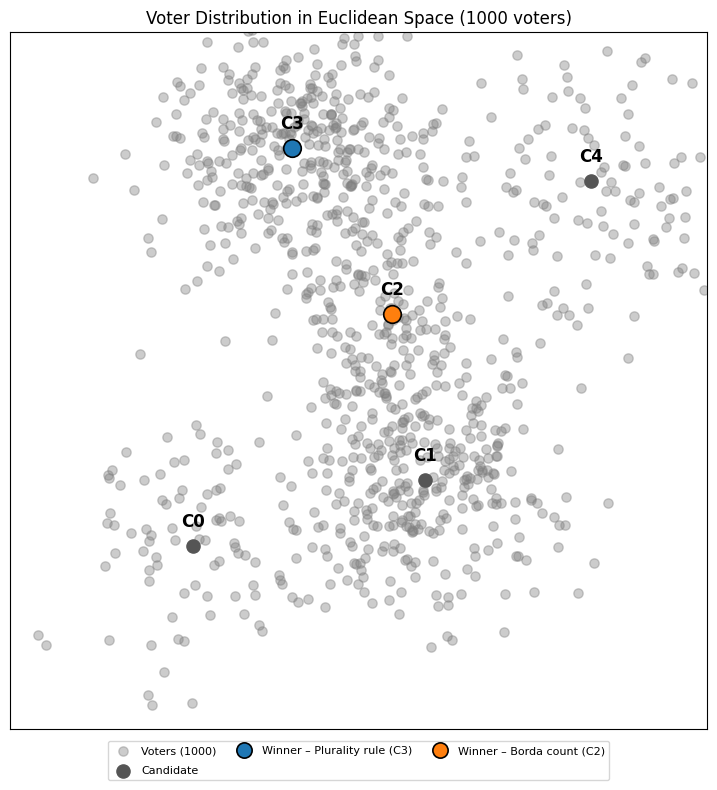

In [6]:
# Sample an initial electorate clustered around the candidates (per `shares`).
voters = sample_voters(candidates, shares, N_VOTERS, sigma=2.0, seed=0)

initial_election_result = Election(
    candidates=candidates, voters=voters
).compare_strategies(strategies)

for s in strategies:
    print(f"{s.name:<15} -> C{candidates.index(initial_election_result.winner(s))}")

print(
    "Tie (two or more candidates within the strategy received equal vote counts): ",
    any(tally.is_tie() for tally in initial_election_result.tallies.values()),
)

plot_results(initial_election_result)

In [7]:
def run_swap(
    model: PermutationSwapLpModel,
    existing_voters: list[Voter],
    strategies: list[VotingStrategy],
    winners: dict[str, int],
) -> PermutationSwapLpModel:
    """
    Solve a swap LP model, then plot and verify the result.

    Parameters
    ----------
    model : PermutationSwapLpModel
        A swap model already configured with target winners,
        a budget (max_added_voters) and an objective.
    existing_voters : list[Voter]
        The fixed electorate, drawn gray on the plot.
    strategies : list[VotingStrategy]
        Rules to check the combined electorate against.
    winners : dict[str, int]
        Target winners mapped as strategy key to candidate index.
    """
    status = model.solve()
    print(f"objective = {model.objective} -> {status}")
    assert status == "Optimal"

    existing = np.array([v.position for v in existing_voters])
    added = model.generate_voter_positions()
    print(f"existing: {len(existing)}, added: {len(added)}\n")

    plot_lp_swap_result(model.candidates, existing, added, winners)

    # Verify on the combined electorate (existing + added).
    combined = np.vstack([existing, added]) if len(added) else existing
    verify_lp_winners(combined, model.candidates, strategies, winners)
    return model

In [8]:
winners = {
    PluralityStrategy.key: 3,
    BordaCountStrategy.key: 1,
}

objective = minmax -> Optimal
existing: 1000, added: 987



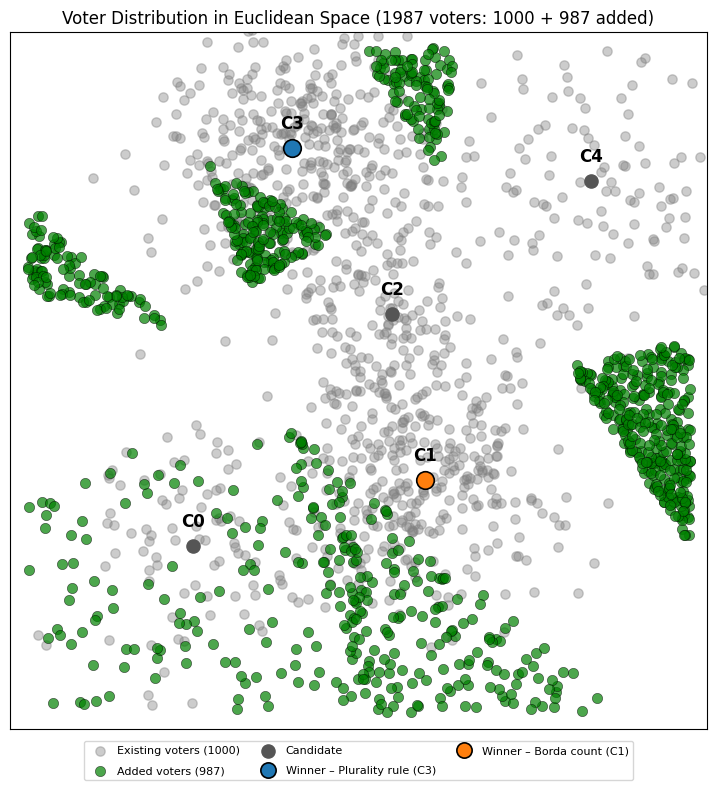

voters: 1987

strategy      target  actual  ok
plurality          3       3  OK
borda              1       1  OK

All winners match - LP model is correct.


In [9]:
# "minmax" objective: spread the added voters as evenly as possible.
model = PermutationSwapLpModel(
    candidates=candidates,
    voters=voters,
    max_added_voters=N_VOTERS,
    winners=winners,
    objective="minmax",
)
_ = run_swap(model, voters, strategies, winners)

objective = maxmin -> Optimal
existing: 1000, added: 1000



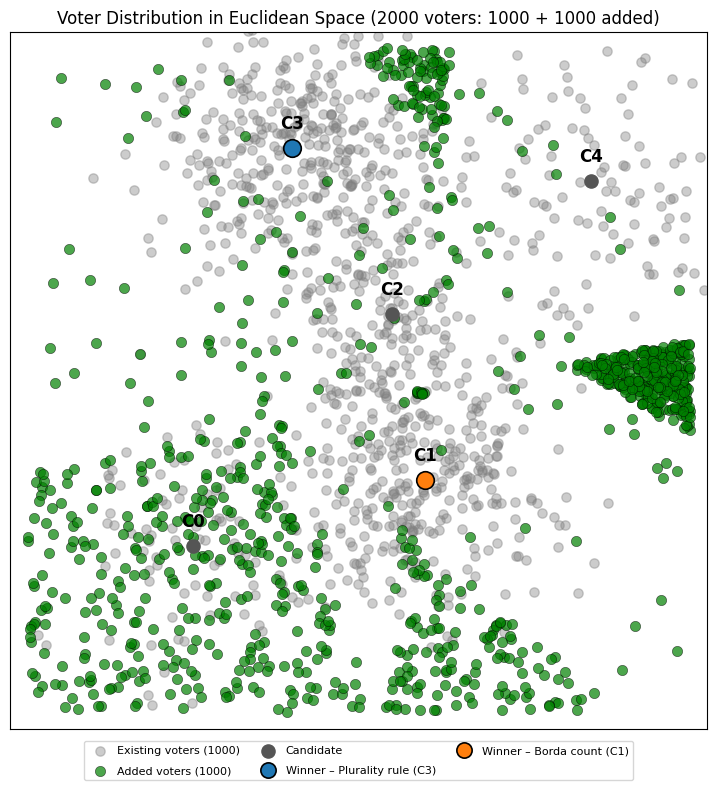

voters: 2000

strategy      target  actual  ok
plurality          3       3  OK
borda              1       1  OK

All winners match - LP model is correct.


In [10]:
# "maxmin" objective: spread all max_added_voters evenly, maximizing the smallest candidate's vote share.
model = PermutationSwapLpModel(
    candidates=candidates,
    voters=voters,
    max_added_voters=N_VOTERS,
    winners=winners,
    objective="maxmin",
)
_ = run_swap(model, voters, strategies, winners)

objective = range -> Optimal
existing: 1000, added: 987



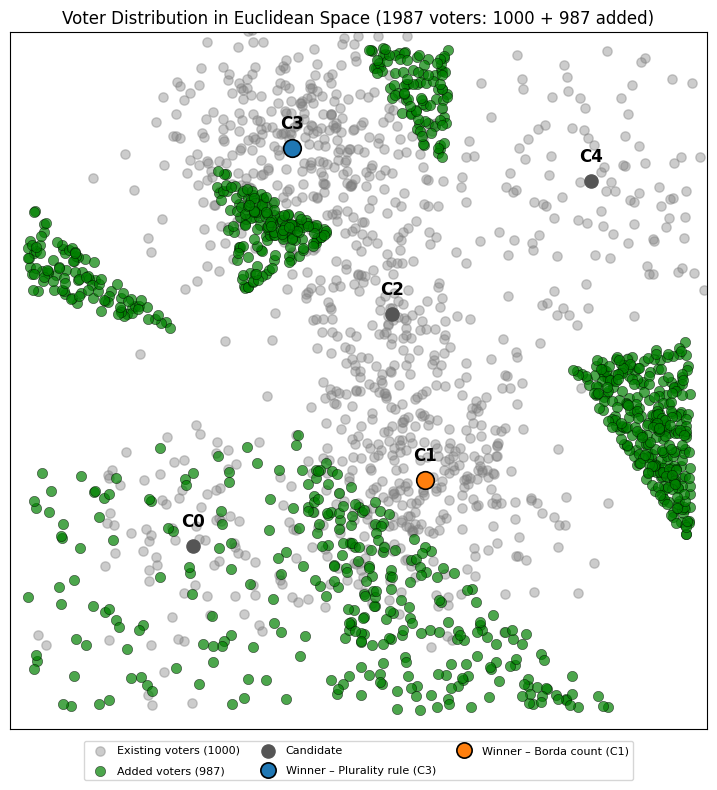

voters: 1987

strategy      target  actual  ok
plurality          3       3  OK
borda              1       1  OK

All winners match - LP model is correct.


In [11]:
# "range" objective: squeeze the spread (max - min bucket).
model = PermutationSwapLpModel(
    candidates=candidates,
    voters=voters,
    max_added_voters=N_VOTERS,
    winners=winners,
    objective="range",
)
_ = run_swap(model, voters, strategies, winners)

objective = min_total -> Optimal
existing: 1000, added: 658



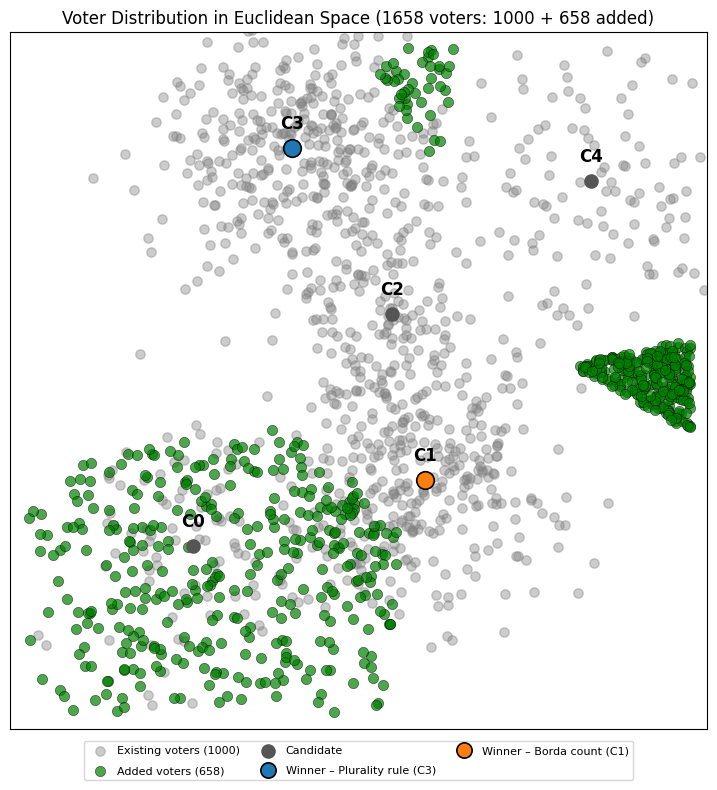

voters: 1658

strategy      target  actual  ok
plurality          3       3  OK
borda              1       1  OK

All winners match - LP model is correct.


In [12]:
# "min_total" objective: use the fewest voters needed (capped at N_VOTERS).
# The solution concentrates added voters in one or two regions.
model = PermutationSwapLpModel(
    candidates=candidates,
    voters=voters,
    max_added_voters=N_VOTERS,
    winners=winners,
    objective="min_total",
)
_ = run_swap(model, voters, strategies, winners)

# Reachable outcomes by adding voters

Starting from the natural outcome of the sampled electorate, we enumerate every possible
winner assignment - the full combination of all strategies and each pair - and check
which ones can be induced by adding voters to the existing electorate.

For each reachable outcome we report the minimum number of voters required.
Assignments that no set of geometrically valid voter positions can produce are marked
`Infeasible` and skipped.

In [13]:
from itertools import product, combinations


def natural_winners(
    model: PermutationSwapLpModel, strategies_subset: list[VotingStrategy]
) -> tuple[int, ...]:
    """Winners of the model's electorate (model.voters), as candidate indices."""
    result = Election(
        candidates=model.candidates, voters=model.voters
    ).compare_strategies(strategies_subset)
    return tuple(
        model.candidates.index(result.winner(strategy))
        for strategy in strategies_subset
    )


def reachable_outcomes(
    model: PermutationSwapLpModel, strategies_subset: list[VotingStrategy]
):
    """
    Scan every winner combination other than the natural one for a given model.

    Parameters
    ----------
    model : LpModel
        A configured LP model with candidates, voters, budget and strategies.
    strategies_subset : list[VotingStrategy]
        The subset of strategies to evaluate winner combinations for.

    Returns
    -------
    natural : dict[str, int]
        The baseline winner assignment produced by the existing electorate.
    reachable : list[tuple[dict[str, int], int]]
        Reachable assignments sorted ascending by the number of added voters required.
    unreachable : list[dict[str, int]]
        Assignments that no set of geometrically valid voter positions can produce.
    """
    keys = [s.key for s in strategies_subset]
    base = natural_winners(model, strategies_subset)

    reachable, unreachable = [], []
    for combo in product(range(model.n_candidates), repeat=len(keys)):
        if combo == base:
            continue
        model.winners = dict(zip(keys, combo))
        model.build()
        if model.solve() != "Optimal":
            unreachable.append(combo)  # no realizable way to produce this combo
            continue
        added = round(sum(v.varValue or 0 for v in model.variables.values()))
        reachable.append((combo, int(added)))

    reachable.sort(key=lambda r: r[1])
    return base, reachable, unreachable

In [14]:
# The sampling pool depends only on candidates and voters, not on the target winners,
# so we build the model once and reuse it across all combinations - only .winners
# and the corresponding constraints are updated per iteration.

# objective="min_total" with a large cap: minimizes the number of added voters,
# giving the true minimum for each combination without an artificial budget limit.

_search_model = PermutationSwapLpModel(
    candidates=candidates,
    voters=voters,
    max_added_voters=N_VOTERS * 2,
    winners={},
    objective="min_total",
    pool_size=100_000,
)
_ = _search_model._sample_pool()  # build & cache the pool a single time

In [15]:
# Scan the full set of strategies, plus each pair (pairs only add something when
# there are 3+ strategies; with exactly 2 the full set already IS the pair).
strategies_subsets = [tuple(strategies)]
if len(strategies) > 2:
    strategies_subsets += list(combinations(strategies, 2))

for subset in strategies_subsets:
    names = " + ".join(s.name for s in subset)
    base, reachable, unreachable = reachable_outcomes(_search_model, list(subset))
    keys = tuple(s.key for s in subset)
    total = len(reachable) + len(unreachable)

    print(f"=== {names} ===")
    print(f"strategies: {keys}")
    print(f"natural outcome: {base}")

    # print(f"reachable ({len(reachable)}):")
    # for combo, added in reachable:
    #     print(f"  -> {combo}: add {added} voters")

    # print(f"NOT reachable ({len(unreachable)}):")
    # for combo in unreachable:
    #     print(f"  -> {combo}")

    print(
        f"summary: {len(reachable)}/{total} reachable, {len(unreachable)}/{total} not\n"
    )

=== Plurality rule + Borda count ===
strategies: ('plurality', 'borda')
natural outcome: (3, 2)
summary: 20/24 reachable, 4/24 not



In [16]:
def run_swap_target(
    candidates: list[Candidate],
    existing_voters: list[Voter],
    strategies: list[VotingStrategy],
    winners,
    objective: str = "min_total",
    max_added_voters: int = N_VOTERS * 2,
) -> LpModel:
    """
    Build a voter-addition LP model for an explicit target, then plot and verify it.

    Thin wrapper over run_swap: it builds the model (accepting the target either as a
    winners dict or as a combo tuple aligned with `strategies`), then delegates the
    solve / plot / verify to run_swap.

    Parameters
    ----------
    candidates : list[Candidate]
        The candidates in the election.
    existing_voters : list[Voter]
        The fixed existing electorate.
    strategies : list[VotingStrategy]
        Strategies the target refers to, used to interpret a combo tuple
        and to verify the combined electorate.
    winners : dict[str, int] or tuple[int, ...]
        Target winner assignment as a winners dict {strategy key: candidate index},
        or a combo tuple aligned with strategies (e.g. a row from the reachability scan).
    objective : str, optional
        How to use the budget. Default is "min_total" (fewest voters added); use
        "minmax"/"maxmin"/"range" to instead spread the added voters for the same target.
    max_added_voters : int, optional
        Budget cap on how many voters may be added.
    """
    target_winners = (
        winners
        if isinstance(winners, dict)
        else {s.key: idx for s, idx in zip(strategies, winners)}
    )

    model = PermutationSwapLpModel(
        candidates=candidates,
        voters=existing_voters,
        max_added_voters=max_added_voters,
        winners=target_winners,
        objective=objective,
    )
    print(f"target winners: {target_winners}")
    return run_swap(model, existing_voters, strategies, target_winners)

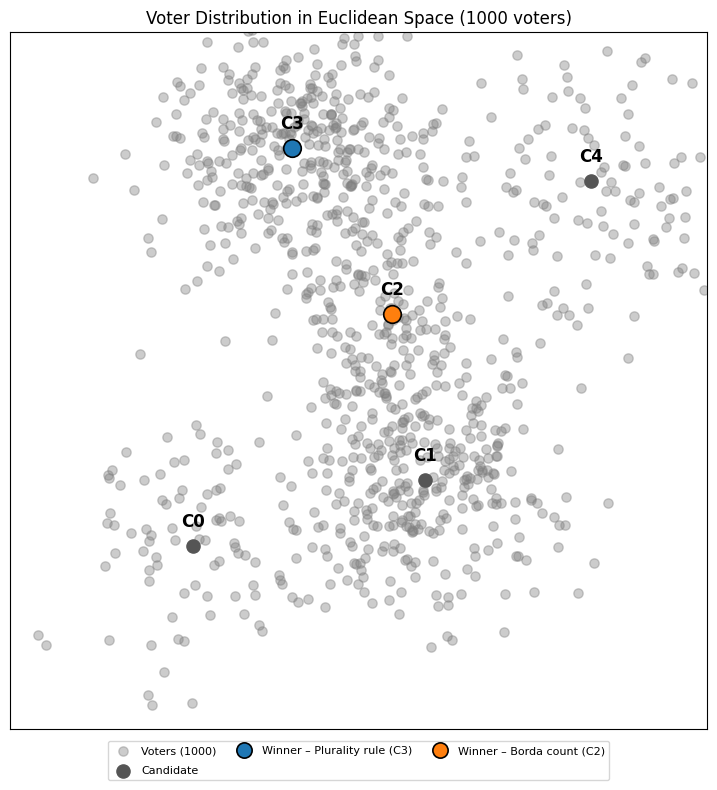

In [17]:
plot_results(initial_election_result)

cheapest flip: (1, 2) (needs 45 added voters)

target winners: {'plurality': 1, 'borda': 2}
objective = min_total -> Optimal
existing: 1000, added: 45



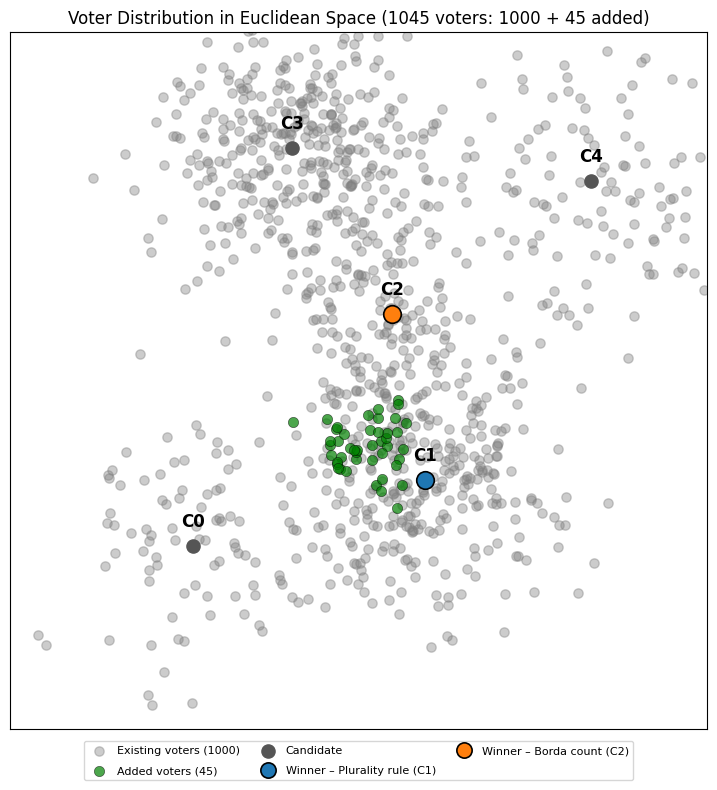

voters: 1045

strategy      target  actual  ok
plurality          1       1  OK
borda              2       2  OK

All winners match - LP model is correct.


In [18]:
# The cheapest reachable flip.
_, reachable, _ = reachable_outcomes(_search_model, list(strategies))
target_combo, n_added = reachable[0]
print(f"cheapest flip: {target_combo} (needs {n_added} added voters)\n")

# Default objective="min_total" => fewest added voters; pass objective="minmax" to spread.
_ = run_swap_target(candidates, voters, strategies, target_combo, objective="min_total")

In [19]:
_cand_pos = np.array([c.position for c in candidates], dtype=float)


def winner_spread(combo, kind="mean"):
    """How far apart the *distinct* winning candidates are.

    kind="mean" -> mean pairwise distance (general spread)
    kind="min"  -> smallest pairwise distance (forces ALL winners far apart)
    Returns 0 if every strategy picks the same candidate.
    """
    idxs = sorted(set(combo))
    if len(idxs) < 2:
        return 0.0
    dists = [
        np.linalg.norm(_cand_pos[i] - _cand_pos[j]) for i, j in combinations(idxs, 2)
    ]
    return float(np.mean(dists) if kind == "mean" else np.min(dists))

natural outcome (3, 2): spread = 5.83

most-dispersed reachable outcomes (* = more spread than natural):
  (0, 3): spread=12.37, add 678 voters *
  (3, 0): spread=12.37, add 1177 voters *
  (3, 1): spread=10.77, add 658 voters *
  (1, 3): spread=10.77, add 1158 voters *
  (4, 1): spread=10.30, add 497 voters *
  (1, 4): spread=10.30, add 1000 voters *
  (0, 2): spread=9.22, add 232 voters *
  (4, 3): spread=9.06, add 673 voters *
  (3, 4): spread=9.06, add 985 voters *
  (0, 1): spread=7.28, add 502 voters *

target winners: {'plurality': 0, 'borda': 3}
objective = min_total -> Optimal
existing: 1000, added: 678



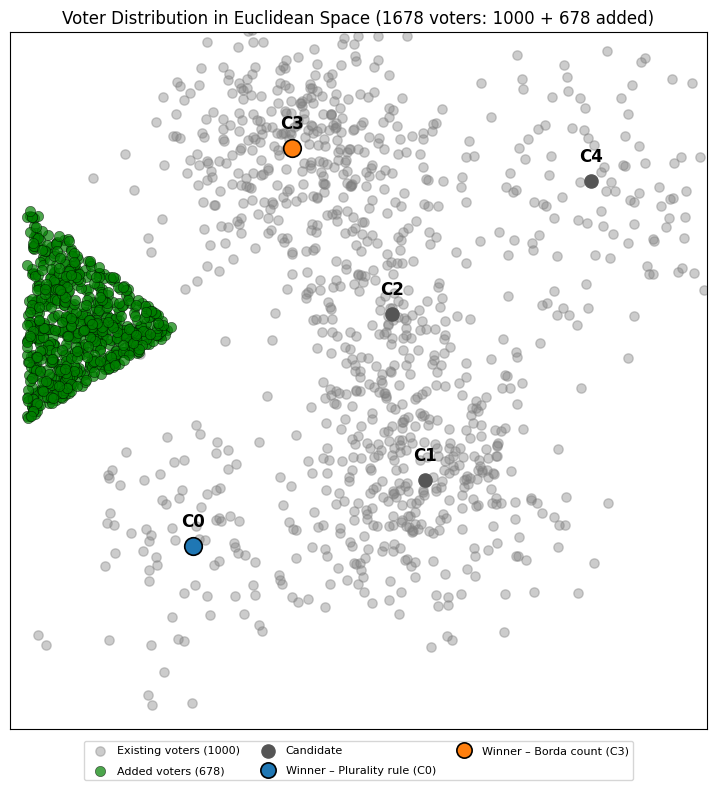

voters: 1678

strategy      target  actual  ok
plurality          0       0  OK
borda              3       3  OK

All winners match - LP model is correct.


In [20]:
# Rank reachable outcomes by how spread-out their winners are, vs. the natural one.
base, reachable, _ = reachable_outcomes(_search_model, list(strategies))
base_spread = winner_spread(base)
print(f"natural outcome {base}: spread = {base_spread:.2f}\n")

# Prefer the most dispersed; break ties by fewest added voters.
ranked = sorted(reachable, key=lambda r: (-winner_spread(r[0]), r[1]))
print("most-dispersed reachable outcomes (* = more spread than natural):")
for combo, added in ranked[:10]:
    sp = winner_spread(combo)
    flag = " *" if sp > base_spread else ""
    print(f"  {combo}: spread={sp:.2f}, add {added} voters{flag}")

# Draw the most spread-out reachable outcome.
best_combo, _ = ranked[0]
print()
_ = run_swap_target(candidates, voters, strategies, best_combo)

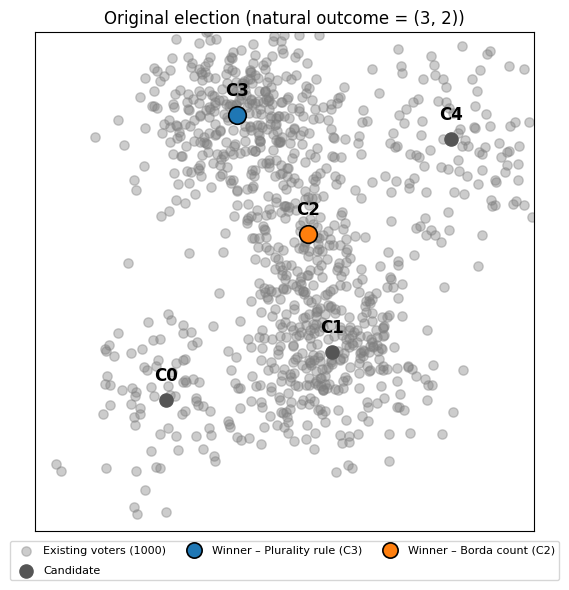

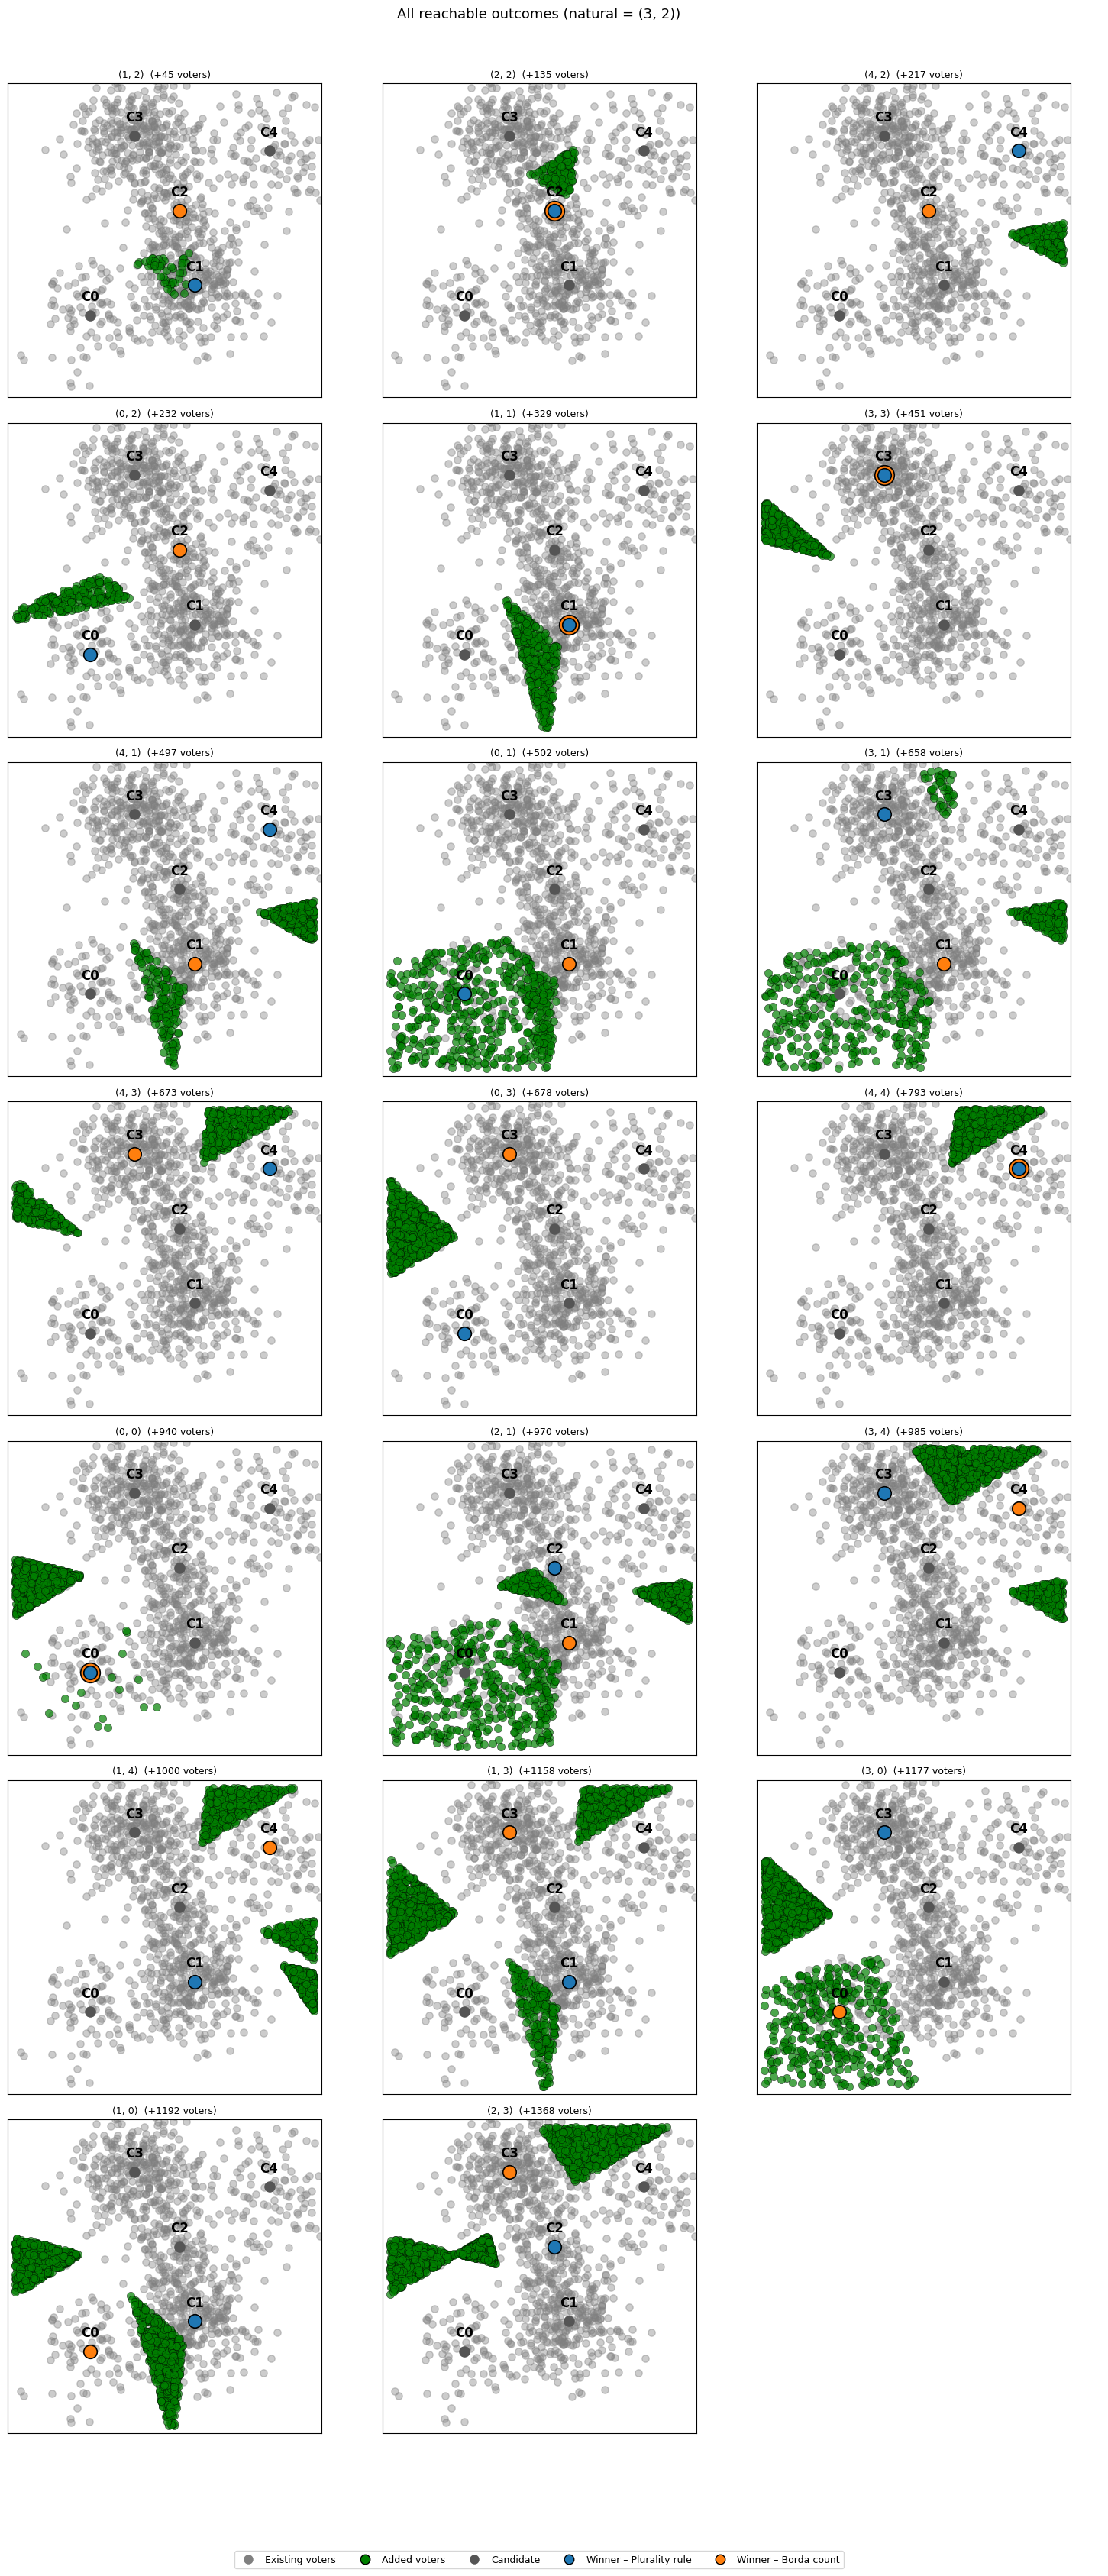

In [21]:
from matplotlib.lines import Line2D

# Reuses `base` and `reachable` from the cell above.
existing = np.array([v.position for v in voters])
no_added = np.empty((0, 2))

# --- original (natural) election result, shown on top ---
natural_winners_d = {s.key: idx for s, idx in zip(strategies, base)}
fig0, ax0 = plt.subplots(figsize=(7, 6))
plot_lp_swap_result(candidates, existing, no_added, natural_winners_d, ax=ax0)
ax0.set_title(f"Original election (natural outcome = {base})")
fig0.tight_layout()
plt.show()

# --- every reachable change, no per-panel legends ---
ncols = 3
nrows = (len(reachable) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4.8))
axes = np.atleast_1d(axes).ravel()

for ax, (combo, added_count) in zip(axes, reachable):
    target = {s.key: idx for s, idx in zip(strategies, combo)}
    _search_model.winners = target
    _search_model.build()
    _search_model.solve()
    added = _search_model.generate_voter_positions()
    plot_lp_swap_result(candidates, existing, added, target, ax=ax, legend=False)
    ax.set_title(f"{combo}  (+{added_count} voters)", fontsize=9)

# Hide any leftover empty subplots.
for ax in axes[len(reachable) :]:
    ax.axis("off")

# One shared legend for the whole grid.
palette = plt.cm.tab10.colors


def legend_dot(color, label, edge="black"):
    return Line2D(
        [],
        [],
        marker="o",
        linestyle="None",
        markerfacecolor=color,
        markeredgecolor=edge,
        markersize=9,
        label=label,
    )


shared = [
    legend_dot("gray", "Existing voters", edge="none"),
    legend_dot("green", "Added voters"),
    legend_dot("#555555", "Candidate", edge="none"),
]
for i, s in enumerate(strategies):
    shared.append(legend_dot(palette[i % len(palette)], f"Winner – {s.name}"))

fig.suptitle(f"All reachable outcomes (natural = {base})", fontsize=13)
fig.legend(
    handles=shared,
    loc="lower center",
    ncols=len(shared),
    fontsize=9,
    bbox_to_anchor=(0.5, -0.02),
)
fig.tight_layout(rect=(0, 0.03, 1, 0.97))
plt.show()